# MediaPipe Face Landmarker — Sanity Check

Run MediaPipe's Face Landmarker (Tasks API, 478 landmarks incl. iris) over sample face crops from different tracks, for both SPEAKING_AUDIBLE and NOT_SPEAKING frames. Visualizes the full face mesh and the mouth/lips subset we'll use downstream, and surfaces cases where detection fails.

## 1. Setup & Imports

### Imports, paths and the FaceLandmarker model

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image as PILImage

import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.core.base_options import BaseOptions

from config import RAW_CSV_DIR, RAW_CLIPS_VIDEOS_DIR, FACE_LANDMARKER_MODEL_PATH, MOUTH_LANDMARK_INDICES

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

assert FACE_LANDMARKER_MODEL_PATH.exists(), f"model not found: {FACE_LANDMARKER_MODEL_PATH}"

landmarker = vision.FaceLandmarker.create_from_options(
    vision.FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(FACE_LANDMARKER_MODEL_PATH)),
        running_mode=vision.RunningMode.IMAGE,
        num_faces=1,
    )
)


2026-07-11 17:47:16.383005: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-11 17:47:16.401424: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-11 17:47:16.418402: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-11 17:47:16.423518: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-11 17:47:16.438087: I tensorflow/core/platform/cpu_feature_guar

### Load the train CSV

In [2]:
train_df = pd.read_csv(RAW_CSV_DIR / "train_orig.csv")
SPEAKING_LABEL_ID = train_df.loc[train_df["label"] == "SPEAKING_AUDIBLE", "label_id"].iloc[0]
print(f"{len(train_df):,} rows, SPEAKING_AUDIBLE -> label_id {SPEAKING_LABEL_ID}")


3,001,883 rows, SPEAKING_AUDIBLE -> label_id 1


## 2. Sample Speaking / Not-Speaking Images Across Different IDs

### Helper to resolve a CSV row's image path

In [3]:
def image_path(row, split="train"):
    return RAW_CLIPS_VIDEOS_DIR / split / row["video_id"] / row["entity_id"] / f'{row["frame_timestamp"]:.2f}.jpg'


### Sample N speaking + N not-speaking rows, one frame per distinct track

In [4]:
N_PER_CLASS = 6

def sample_one_per_track(df, n, seed):
    shuffled = df.sample(frac=1, random_state=seed)
    one_per_track = shuffled.drop_duplicates(subset="entity_id", keep="first")
    return one_per_track.sample(n=min(n, len(one_per_track)), random_state=seed)

speaking_samples = sample_one_per_track(train_df[train_df["label_id"] == SPEAKING_LABEL_ID], N_PER_CLASS, seed=0)
not_speaking_samples = sample_one_per_track(train_df[train_df["label_id"] != SPEAKING_LABEL_ID], N_PER_CLASS, seed=1)

samples = pd.concat([speaking_samples, not_speaking_samples], ignore_index=True)
samples[["video_id", "entity_id", "frame_timestamp", "label"]]


,video_id,entity_id,frame_timestamp,label
0,gIwp3J7Iny0,gIwp3J7Iny0:390,434.88,SPEAKING_AUDIBLE
1,HEKmJiNxN5s,HEKmJiNxN5s:738,748.64,SPEAKING_AUDIBLE
2,QdKx5xzNcNc,QdKx5xzNcNc:230,744.04,SPEAKING_AUDIBLE
3,vMyLXad6AFY,vMyLXad6AFY:362,442.24,SPEAKING_AUDIBLE
4,59IKR_YVeps,59IKR_YVeps:287,254.04,SPEAKING_AUDIBLE
5,iBa-95Tk4ZM,iBa-95Tk4ZM:323,320.36,SPEAKING_AUDIBLE
6,K9HFt9E0ixg,K9HFt9E0ixg:343,651.24,NOT_SPEAKING
7,HYTRyz1syvw,HYTRyz1syvw:177,185.60,NOT_SPEAKING
8,ICISHNou9Zs,ICISHNou9Zs:16,24.48,NOT_SPEAKING
9,wit3xhN2frY,wit3xhN2frY:341,405.88,NOT_SPEAKING


## 3. Run MediaPipe Face Landmarker on the Samples

### Detection helper: image path -> (image array, 478 landmarks or None)

In [5]:
def detect_landmarks(img_path):
    img = np.array(PILImage.open(img_path).convert("RGB"))
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)
    result = landmarker.detect(mp_image)
    if not result.face_landmarks:
        return img, None
    return img, result.face_landmarks[0]


def landmarks_to_xy(lm, w, h):
    return np.array([[p.x * w, p.y * h] for p in lm])


### Run detection on every sampled image

In [6]:
results = []
for _, row in samples.iterrows():
    img, lm = detect_landmarks(image_path(row))
    results.append({"row": row, "image": img, "landmarks": lm})

n = len(results)
cols = 4
rows = int(np.ceil(n / cols))
detected = sum(r["landmarks"] is not None for r in results)
print(f"detected a face in {detected}/{n} sampled images")


detected a face in 6/12 sampled images


## 4. Visualize Full-Face Landmarks

### Draw all 478 landmarks over each sampled image

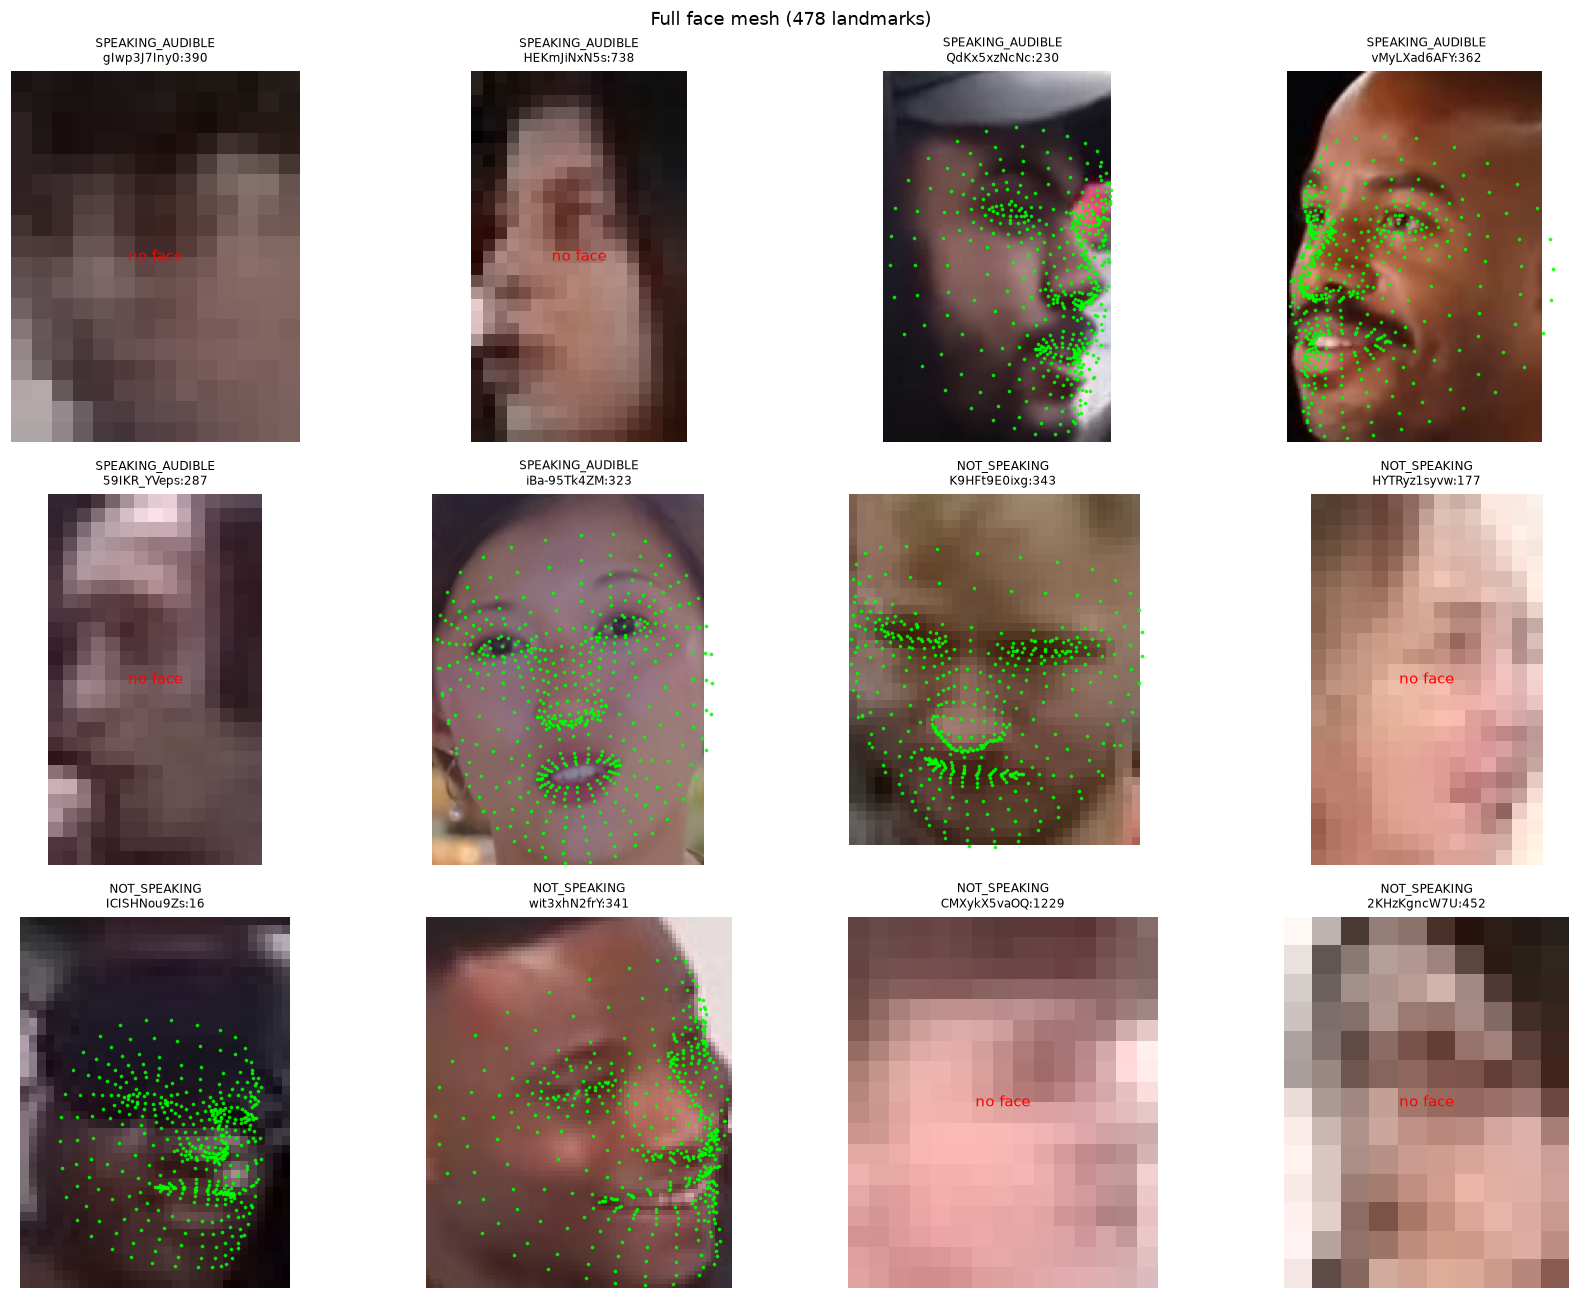

In [7]:
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
for ax, r in zip(axes.flat, results):
    img, lm, row = r["image"], r["landmarks"], r["row"]
    ax.imshow(img)
    if lm is not None:
        h, w = img.shape[:2]
        pts = landmarks_to_xy(lm, w, h)
        ax.scatter(pts[:, 0], pts[:, 1], s=2, c="lime", alpha=0.8)
    else:
        ax.text(0.5, 0.5, "no face", ha="center", va="center", transform=ax.transAxes, color="red")
    ax.set_title(f'{row["label"]}\n{row["entity_id"]}', fontsize=8)
    ax.axis("off")
for ax in axes.flat[n:]:
    ax.axis("off")
fig.suptitle("Full face mesh (478 landmarks)")
fig.tight_layout()
plt.show()


## 5. Visualize Mouth-Only Landmarks

### Draw just the mouth-landmark subset with lip contour

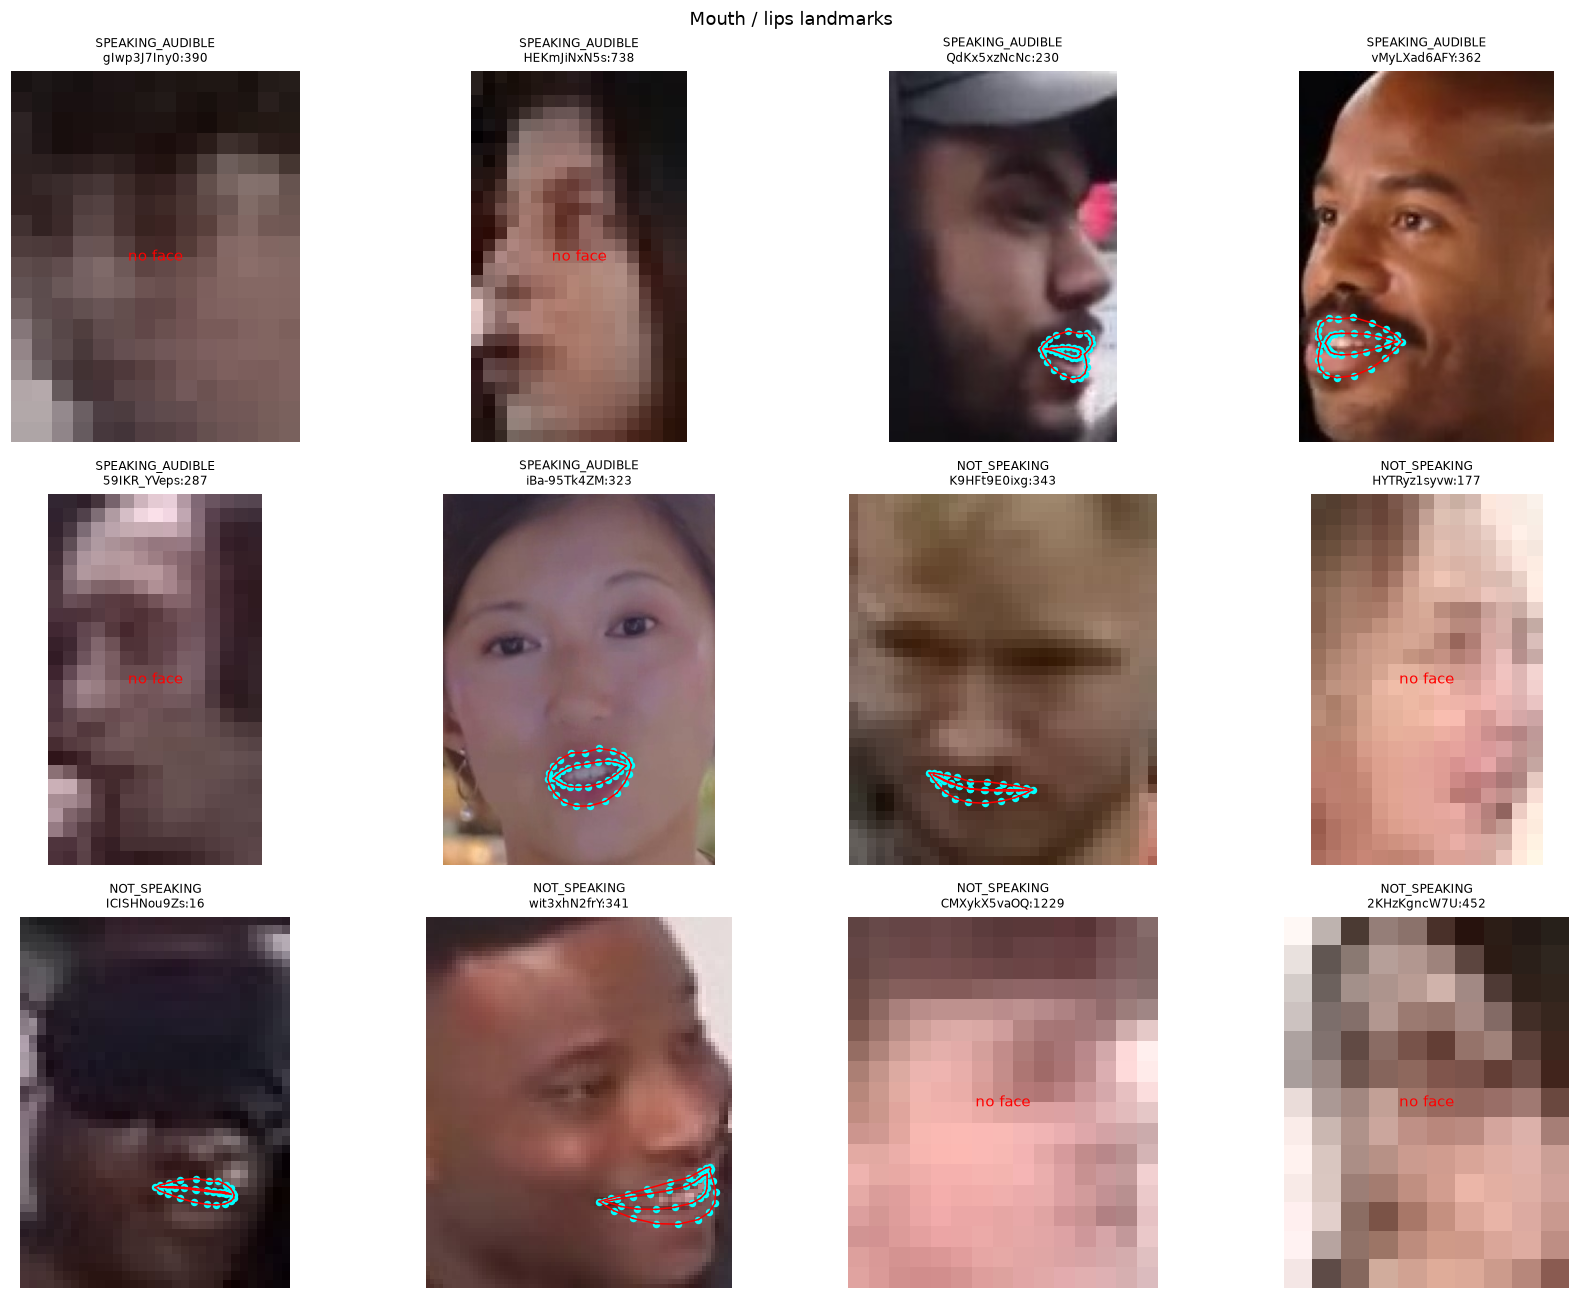

In [8]:
from mediapipe.tasks.python.vision import FaceLandmarksConnections

lips_connections = [(c.start, c.end) for c in FaceLandmarksConnections.FACE_LANDMARKS_LIPS]

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
for ax, r in zip(axes.flat, results):
    img, lm, row = r["image"], r["landmarks"], r["row"]
    ax.imshow(img)
    if lm is not None:
        h, w = img.shape[:2]
        pts = landmarks_to_xy(lm, w, h)
        for i, j in lips_connections:
            ax.plot(pts[[i, j], 0], pts[[i, j], 1], c="red", linewidth=1)
        mouth_pts = pts[MOUTH_LANDMARK_INDICES]
        ax.scatter(mouth_pts[:, 0], mouth_pts[:, 1], s=15, c="cyan")
    else:
        ax.text(0.5, 0.5, "no face", ha="center", va="center", transform=ax.transAxes, color="red")
    ax.set_title(f'{row["label"]}\n{row["entity_id"]}', fontsize=8)
    ax.axis("off")
for ax in axes.flat[n:]:
    ax.axis("off")
fig.suptitle("Mouth / lips landmarks")
fig.tight_layout()
plt.show()


### Zoomed-in mouth crops, speaking vs not-speaking

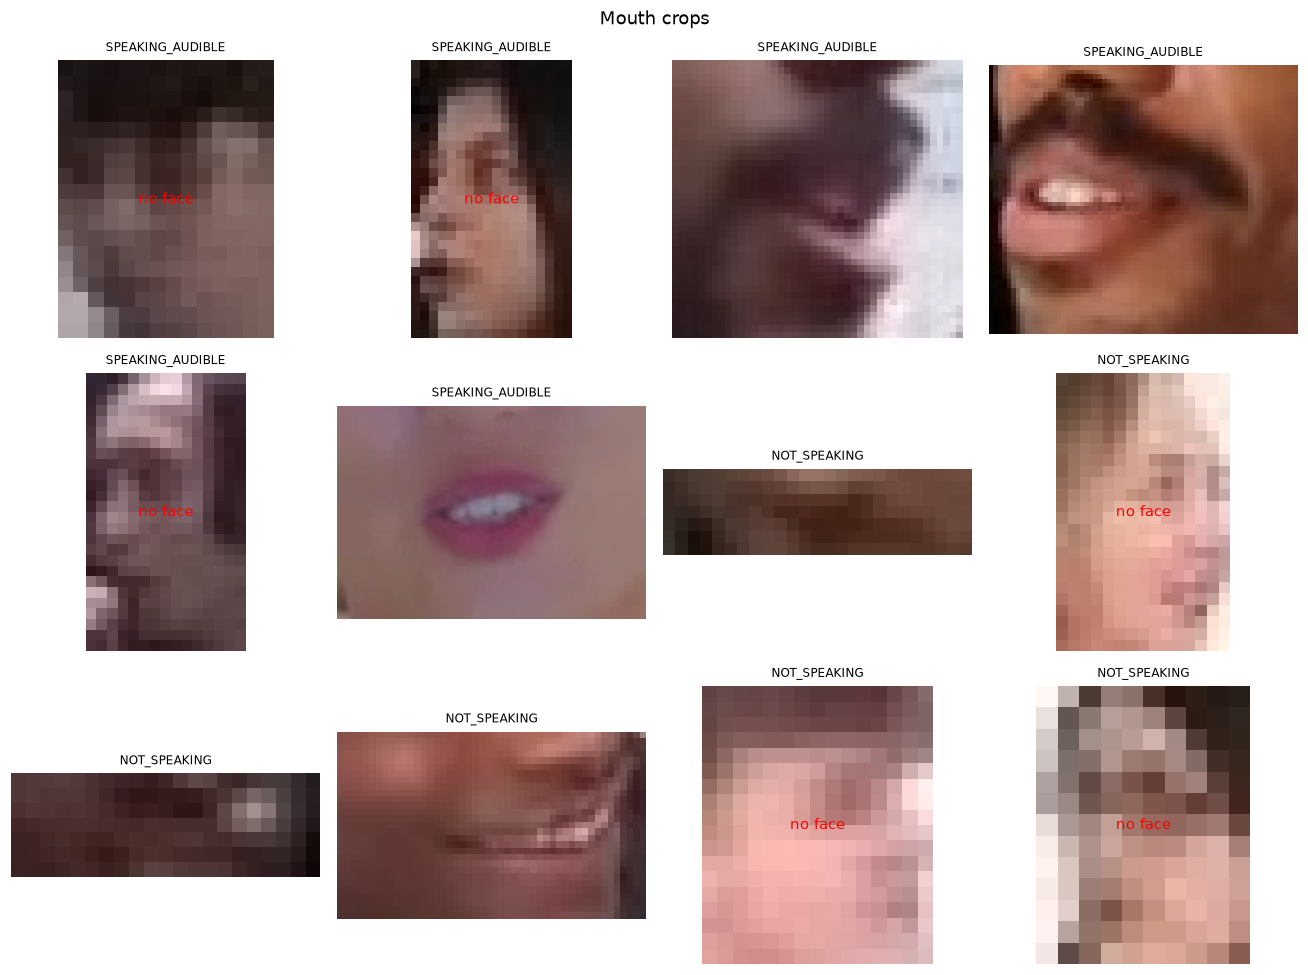

In [9]:
def mouth_crop(img, pts, margin=0.6):
    x0, y0 = pts[:, 0].min(), pts[:, 1].min()
    x1, y1 = pts[:, 0].max(), pts[:, 1].max()
    w, h = x1 - x0, y1 - y0
    x0, x1 = x0 - margin * w, x1 + margin * w
    y0, y1 = y0 - margin * h, y1 + margin * h
    x0, y0 = max(0, int(x0)), max(0, int(y0))
    x1, y1 = min(img.shape[1], int(x1)), min(img.shape[0], int(y1))
    return img[y0:y1, x0:x1]

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for ax, r in zip(axes.flat, results):
    img, lm, row = r["image"], r["landmarks"], r["row"]
    if lm is not None:
        h, w = img.shape[:2]
        pts = landmarks_to_xy(lm, w, h)[MOUTH_LANDMARK_INDICES]
        ax.imshow(mouth_crop(img, pts))
    else:
        ax.imshow(img)
        ax.text(0.5, 0.5, "no face", ha="center", va="center", transform=ax.transAxes, color="red")
    ax.set_title(row["label"], fontsize=8)
    ax.axis("off")
for ax in axes.flat[n:]:
    ax.axis("off")
fig.suptitle("Mouth crops")
fig.tight_layout()
plt.show()


## 6. Quick Mouth-Openness Signal Check

### Compute a simple mouth-aspect-ratio (MAR) per sampled image

In [10]:
def mouth_aspect_ratio(lm, w, h):
    pts = landmarks_to_xy(lm, w, h)
    vertical = np.linalg.norm(pts[13] - pts[14])    # inner-lip top/bottom
    horizontal = np.linalg.norm(pts[78] - pts[308])  # mouth corners
    return vertical / horizontal

mar_rows = []
for r in results:
    if r["landmarks"] is None:
        continue
    h, w = r["image"].shape[:2]
    mar_rows.append({"label": r["row"]["label"], "entity_id": r["row"]["entity_id"],
                      "mar": mouth_aspect_ratio(r["landmarks"], w, h)})

mar_df = pd.DataFrame(mar_rows)
mar_df


,label,entity_id,mar
0,SPEAKING_AUDIBLE,QdKx5xzNcNc:230,0.278970
1,SPEAKING_AUDIBLE,vMyLXad6AFY:362,0.300125
2,SPEAKING_AUDIBLE,iBa-95Tk4ZM:323,0.307173
3,NOT_SPEAKING,K9HFt9E0ixg:343,0.004566
4,NOT_SPEAKING,ICISHNou9Zs:16,0.019010
5,NOT_SPEAKING,wit3xhN2frY:341,0.166945


### MAR by label (speaking vs not) — quick eyeball check

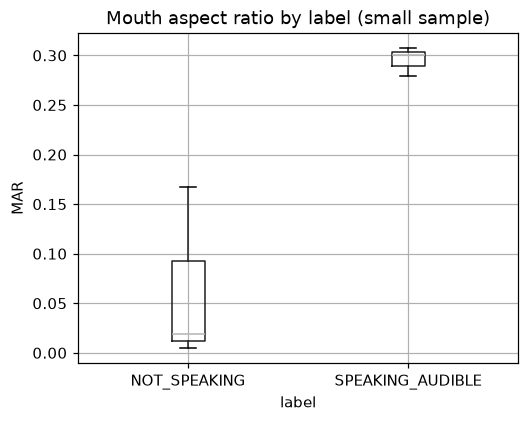

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
mar_df.boxplot(column="mar", by="label", ax=ax)
ax.set_title("Mouth aspect ratio by label (small sample)")
ax.set_ylabel("MAR")
plt.suptitle("")
plt.show()


## 7. Failure Cases

### Sample a larger batch to look for detection failures

In [12]:
FAILURE_SCAN_N = 60
big_sample = (
    train_df.sample(frac=1, random_state=2)
    .drop_duplicates(subset="entity_id", keep="first")
    .sample(FAILURE_SCAN_N, random_state=2)
)

failures = []
for _, row in big_sample.iterrows():
    img, lm = detect_landmarks(image_path(row))
    if lm is None:
        failures.append({"row": row, "image": img})

print(f"{len(failures)}/{FAILURE_SCAN_N} failed to detect a face")


33/60 failed to detect a face


### Visualize a few failure images

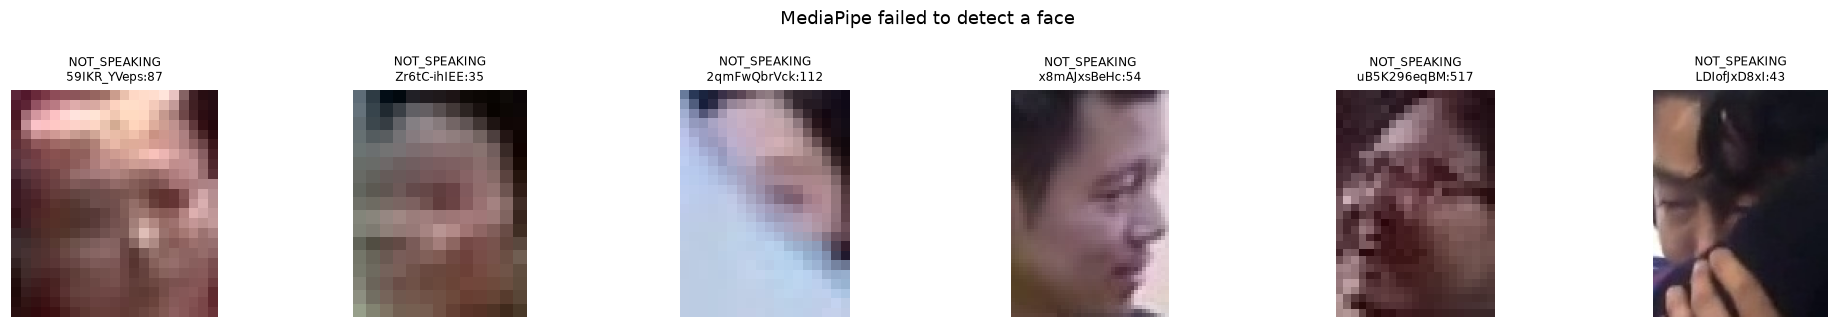

In [13]:
if failures:
    n_show = min(6, len(failures))
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
    axes = np.atleast_1d(axes)
    for ax, f in zip(axes, failures[:n_show]):
        ax.imshow(f["image"])
        ax.set_title(f'{f["row"]["label"]}\n{f["row"]["entity_id"]}', fontsize=8)
        ax.axis("off")
    fig.suptitle("MediaPipe failed to detect a face")
    fig.tight_layout()
    plt.show()
else:
    print("no failures in this sample — try a bigger FAILURE_SCAN_N")


## 8. Summary

### Detection success rate and notes

In [14]:
print(f"Small sanity sample: {detected}/{n} detected ({detected / n * 100:.1f}%)")
ok = FAILURE_SCAN_N - len(failures)
print(f"Larger scan ({FAILURE_SCAN_N} tracks): {ok}/{FAILURE_SCAN_N} detected ({ok / FAILURE_SCAN_N * 100:.1f}%)")


Small sanity sample: 6/12 detected (50.0%)
Larger scan (60 tracks): 27/60 detected (45.0%)
